In [1]:
!nvidia-smi

Wed Apr 22 16:09:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   25C    P8             24W /  300W |       1MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%env CUDA_VISIBLE_DEVICES=2

env: CUDA_VISIBLE_DEVICES=2


In [ ]:
import json
import math
import os
import zipfile
import glob
import importlib
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # -> consistency/
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

import consistency_models.consistency_models_VarCM as _cm_var
importlib.reload(_cm_var)

from consistency_models.consistency_models_VarCM import (
    VariationalConsistencyTraining,
    VariationalConsistencySampling,
    model_variational_forward_wrapper,
)
from consistency_models.utils import update_ema_model_

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("[WARNING] properscoring not installed -- CRPS disabled. Install with: pip install properscoring")

## Implementation

### DataModule -- SPDE Diffusion Dataset

In [4]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "/data/users/maxb/4dvarnet-starter-devs/SPDE/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB ...
    y          (time, lat, lon) float32 20MB ...
    OI         (time, lat, lon) float64 39MB ...
    H11        (lat, lon) float32 66kB ...
    H22        (lat, lon) float32 66kB ...
    H12        (lat, lon) float32 66kB ...
    Time       (time) int64 2kB ...
    longitude  (lon) int64 1kB ...
    latitude   (lat) int64 1kB ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('la

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45

[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes -- input (y): (5, 128, 128), tgt (x): (5, 128, 128)
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes -- input (y): (5, 128, 128), tgt (x): (5, 128, 128)


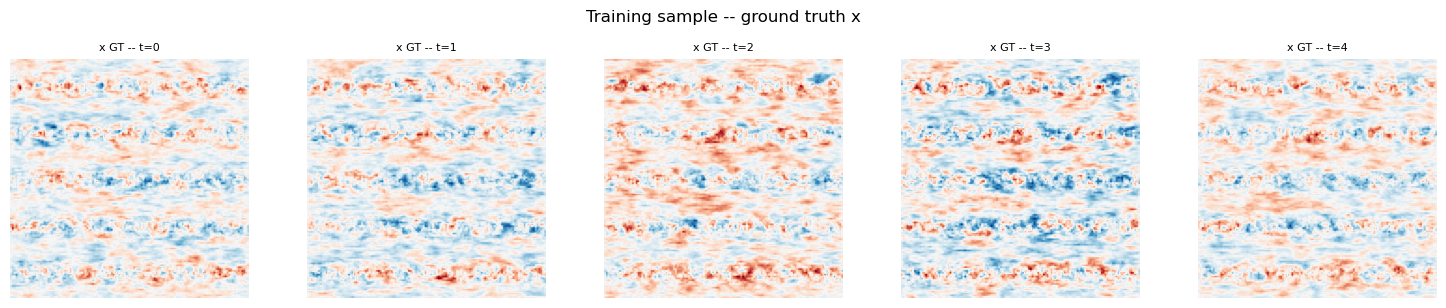

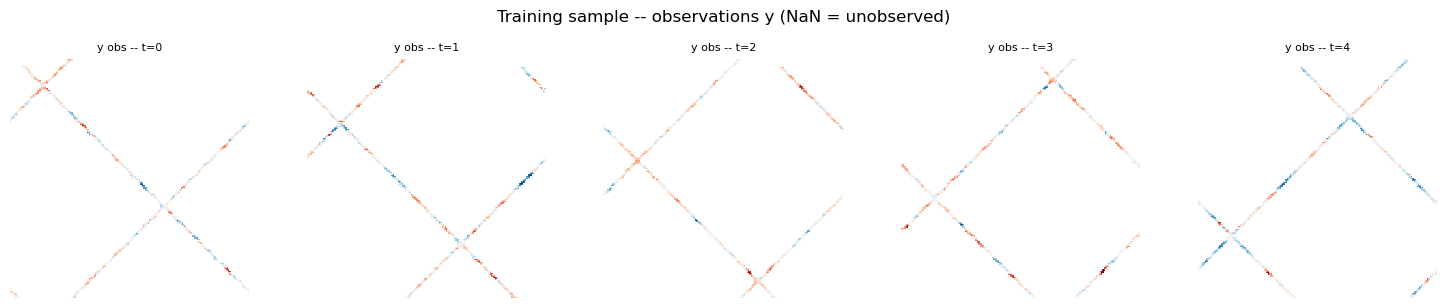

In [5]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes -- input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT -- t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample -- ground truth x", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs -- t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample -- observations y (NaN = unobserved)", y=1.01)
plt.tight_layout()
plt.show()

### UNet Building Blocks

GroupNorm, SelfAttention, UNetBlock, Downsample, Upsample, `TimeEmbedding` (for **t** and **t'** separately), `_pad_to_multiple`, `_unpad`.

In [6]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeEmbedding(nn.Module):
    """Fourier time embedding for a scalar t in [0, 1]."""
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Padding utilities (100x100 -> 104x104, multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### Variational UNet

Differences vs the classic PWCM UNet:
- **`input_projection`**: takes `c_in(t) * x` -- **C** channels (not 3C)
- **`grad_j_projection`**: takes `grad_J` -- **C** channels, added to the output of `input_projection`
- **Two `TimeEmbedding`**: one for `t`, one for `t'`, concatenated -> `2 x time_level_channels`
- No observations y in the forward pass (handled upstream via `model_variational_forward_wrapper`)

In [7]:
@dataclass
class UNetConfig:
    channels: int = 5                                        # = window_size
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class UNet(nn.Module):
    """
    Variational UNet: takes (c_in*x, cond, t, t') as input.

    Two conditioning modes (selected automatically from cond.shape[1]):
      - grad mode : cond = grad_J  (C channels)  -> grad_j_projection (C -> top)
      - obs  mode : cond = cat([y_filled, mask])  (2C channels) -> obs_projection (2C -> top)

    - input_projection  : C  -> top_ch[0]  (for c_in*x)
    - Two TimeEmbedding concatenated -> conditioning 2xTLC
    """
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        top = config.top_blocks_channels[0]

        # x projection (always C channels)
        self.input_projection  = nn.Conv2d(C,     top, kernel_size=3, padding="same")
        # grad mode: C channels  (grad_J, normalised to unit std)
        self.grad_j_projection = nn.Conv2d(C,     top, kernel_size=3, padding="same")
        # obs  mode: 2C channels (y_filled + mask)
        self.obs_projection    = nn.Conv2d(2 * C, top, kernel_size=3, padding="same")

        # One embedding per solver time (t and t')
        self.time_embedding_t  = TimeEmbedding(config.time_level_channels, config.time_level_scale)
        self.time_embedding_tp = TimeEmbedding(config.time_level_channels, config.time_level_scale)

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.output_projection = nn.Conv2d(top, C, kernel_size=3, padding="same")

    def forward(self, x: Tensor, cond: Tensor, t: Tensor, t_prime: Tensor) -> Tensor:
        """
        x    : (B, C,   H, W)  -- c_in(t) * current state
        cond : (B, C,   H, W)  -- grad_J  (grad mode, C channels)
             | (B, 2C,  H, W)  -- cat([y_filled, mask])  (obs mode, 2C channels)
        t, t_prime : (B,)
        """
        x,    px = _pad_to_multiple(x,    multiple=8)
        cond, _  = _pad_to_multiple(cond, multiple=8)

        # Route conditioning to the appropriate projection
        if cond.shape[1] == self.config.channels:
            cond_proj = self.grad_j_projection(cond)
        else:
            cond_proj = self.obs_projection(cond)

        h = self.input_projection(x) + cond_proj

        # Conditioning: t and t' -> concat on channel dim
        emb_t  = self.time_embedding_t(t)
        emb_tp = self.time_embedding_tp(t_prime)
        time_level = torch.cat([emb_t, emb_tp], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, px)

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# Sanity check -- test both conditioning modes
C = datamodule.window_size
_unet = UNet(UNetConfig(channels=C))
summary(
    _unet,
    input_size=(
        (1, C, 100, 100),       # x (c_in * x)
        (1, C, 100, 100),       # cond: grad mode (C channels)
        (1,),                    # t
        (1,),                    # t'
    ),
    col_names=["input_size", "output_size", "num_params"],
    verbose=0,
)
# torchinfo may move the model to GPU during the forward pass -- bring it back to CPU
_unet = _unet.cpu()

# Quick forward check: obs mode (2C channels)
_x_dummy  = torch.randn(1, C, 100, 100)
_cond_obs = torch.randn(1, 2 * C, 100, 100)
_t_dummy  = torch.rand(1)
with torch.no_grad():
    _out = _unet(_x_dummy, _cond_obs, _t_dummy, _t_dummy)
print(f"[OK] UNet obs-mode forward: input {_x_dummy.shape} + cond {_cond_obs.shape} -> output {_out.shape}")


[OK] UNet obs-mode forward: input torch.Size([1, 5, 100, 100]) + cond torch.Size([1, 10, 100, 100]) -> output torch.Size([1, 5, 100, 100])


### Variational Costs

- **`BaseObsCost`**: $J_o(x, y) = \|M(x - y)\|^2$ (NaN mask)
- **`BilinAEPriorCost`**: $J_b(x) = \|x - \Phi(x)\|^2$ with $\Phi$ = bilinear auto-encoder
- **`lambda_reg`**: `nn.Parameter` scalar $\geq 0$ weighting $J_b$ in $J = J_o + \lambda J_b$

In [8]:
class BaseObsCost(nn.Module):
    """
    Quadratic observation cost: J_o(x, y) = ||M*(x - y)||^2 / (2 * sigma_obs^2)
    M = binary mask (1 where y is observed, 0 where y is NaN).
    """
    def __init__(self, sigma_obs: float = 1.0) -> None:
        super().__init__()
        self.sigma_obs = sigma_obs

    def forward(self, x: Tensor, y: Tensor) -> Tensor:
        """Returns a scalar."""
        mask = (~torch.isnan(y)).to(dtype=x.dtype)
        y_c  = torch.nan_to_num(y, nan=0.0)
        diff = mask * (x - y_c)
        return (diff ** 2).sum() / (2.0 * self.sigma_obs ** 2)


class BilinAEPriorCost(nn.Module):
    """
    Prior cost based on a bilinear auto-encoder:
        J_b(x) = ||x - Phi(x)||^2

    Phi = standard BilinAE (Conv encoder -> Conv decoder with bilinear interaction).
    dim_in: number of input channels (= window_size)
    """
    def __init__(self, dim_in: int = 5, dim_ae: int = 32) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(dim_in, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
        )
        self.decoder_lin = nn.Sequential(
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_in, 3, padding=1),
        )
        self.decoder_quad = nn.Sequential(
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_in, 3, padding=1),
        )

    def forward_ae(self, x: Tensor) -> Tensor:
        """Returns Phi(x)."""
        z = self.encoder(x)
        return self.decoder_lin(z) + self.decoder_quad(z) ** 2

    def forward(self, x: Tensor) -> Tensor:
        """Returns J_b(x) = ||x - Phi(x)||^2 (scalar)."""
        recon = self.forward_ae(x)
        return F.mse_loss(x, recon) * x.numel()


# Sanity check
C = datamodule.window_size
_x_test = torch.randn(2, C, 100, 100)
_y_test = torch.randn(2, C, 100, 100)
_y_test[0, :, :10, :10] = float('nan')   # simulate NaN observations
_obs  = BaseObsCost(sigma_obs=1.0)
_prior = BilinAEPriorCost(dim_in=C)
print("J_o =", _obs(_x_test, _y_test).item())
print("J_b =", _prior(_x_test).item())
print("Phi(x) shape =", _prior.forward_ae(_x_test).shape)

J_o = 99515.1953125
J_b = 100429.59375
Phi(x) shape = torch.Size([2, 5, 100, 100])


### LightningModule -- LitConsistencyModel (Variational)

In [ ]:

@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    lambda_reg_init: float = 1.0
    total_training_steps: int = 5_000   # N: 3 -> 17 in ~30 epochs


class LitConsistencyModel(LightningModule):
    def __init__(
        self,
        consistency_training: VariationalConsistencyTraining,
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        obs_cost: BaseObsCost,
        prior_cost: BilinAEPriorCost,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()
        self.consistency_training = consistency_training
        self.student_model = student_model
        self.teacher_model = teacher_model
        self.ema_student_model = ema_student_model
        self.obs_cost   = obs_cost
        self.prior_cost = prior_cost
        self.config = config
        self.num_timesteps = self.consistency_training.initial_timesteps

        # lambda_reg: learned scalar parameter >= 0
        self.lambda_reg = nn.Parameter(
            torch.tensor(config.lambda_reg_init, dtype=torch.float32)
        )

        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model     = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def on_train_epoch_start(self) -> None:
        warmup_ep = self.consistency_training.warmup_epochs
        bw = max(0.0, 1.0 - self.current_epoch / max(1, warmup_ep))
        print(f"[Epoch {self.current_epoch}] num_timesteps={self.num_timesteps}  "
              f"lambda_reg={self.lambda_reg.item():.4f}  beta_w={bw:.3f}")

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        # Clamp lambda_reg >= 0 at each step
        self.lambda_reg.data.clamp_(min=0.0)

        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            self.obs_cost,
            self.prior_cost,
            self.lambda_reg,
            batch.tgt,
            batch.input,
            self.global_step,
            self.config.total_training_steps,
        )
        self.num_timesteps = output.num_timesteps

        loss, l_pair, l_interp, l_prior, l_direct, beta_w = \
            self.consistency_training.compute_loss(output, self.current_epoch)

        if batch_idx % 10 == 0:
            N = output.num_timesteps
            times_str = "  ".join(f"{v:.3f}" for v in output.times.tolist())
            t   = output.t_sampled[0].item()
            tp  = output.t_prime_sampled[0].item()
            tpp = output.t_pp_sampled[0].item()
            print(
                f"[Ep {self.current_epoch} | step {self.global_step}]  N={N}\n"
                f"  grid    : [{times_str}]\n"
                f"  sampled : t={t:.3f}  t'={tp:.3f}  t''={tpp:.3f}\n"
                f"  L={loss.item():.4f}  L_pair={l_pair.item():.4f}  "
                f"L_interp={l_interp.item():.4f}  L_direct={l_direct.item():.4f}  "
                f"L_prior={l_prior.item():.4f}  beta_w={beta_w:.3f}"
            )

        self.log_dict({
            "train_loss":    loss,
            "L_pair":        l_pair,
            "L_interp":      l_interp,
            "L_prior":       l_prior,
            "L_direct":      l_direct,
            "beta_w":        float(beta_w),
            "lambda_reg":    self.lambda_reg.detach(),
            "num_timesteps": float(output.num_timesteps),
        }, prog_bar=False)
        return loss

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        from consistency_models.consistency_models_VarCM import (
            VariationalConsistencyTraining as _VCT,
        )
        # EMA teacher <- student  (decay depends on current number of timesteps)
        from consistency_models.consistency_models_CM import (
            ema_decay_rate_schedule,
        )
        ema_decay_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model,     self.student_model, ema_decay_rate)
        update_ema_model_(self.ema_student_model, self.student_model,
                          self.config.student_model_ema_decay_rate)
        self.log("ema_decay_rate", ema_decay_rate)

    def configure_optimizers(self):
        params = (
            list(self.student_model.parameters())
            + list(self.obs_cost.parameters())
            + list(self.prior_cost.parameters())
            + [self.lambda_reg]
        )
        opt = torch.optim.Adam(params, lr=self.config.lr, betas=self.config.betas)
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]


## Training

In [10]:
%tensorboard --logdir=logs_CT_VarCM_spde --port 6008

UsageError: Line magic function `%tensorboard` not found.


In [ ]:

# Force-reload the module to avoid kernel cache
import importlib
import consistency_models.consistency_models_VarCM as _vcm_mod
importlib.reload(_vcm_mod)
from consistency_models.consistency_models_VarCM import (
    VariationalConsistencyTraining,
    VariationalConsistencySampling,
)

RESET_TRAINING = False   # <<< c_in fix: incompatible with old checkpoints -- retrain
RESUME_FROM_LAST = True  # Set True to resume from last.ckpt instead of best valid checkpoint

def is_valid_checkpoint(path: str) -> bool:
    try:
        ckpt = torch.load(path, map_location="cpu")
        state = ckpt.get("state_dict", {})
        for v in state.values():
            if torch.is_tensor(v) and torch.isnan(v).any():
                return False
        return True
    except Exception:
        return False


def find_best_valid_checkpoint(ckpt_dir: str, use_last: bool = True) -> Optional[str]:
    """Returns a checkpoint to resume from.

    Parameters
    ----------
    ckpt_dir  : directory containing .ckpt files
    use_last  : if True, return last.ckpt (if valid) instead of best by train_loss
    """
    if not os.path.isdir(ckpt_dir):
        return None

    if use_last:
        last_path = os.path.join(ckpt_dir, "last.ckpt")
        if os.path.isfile(last_path):
            if is_valid_checkpoint(last_path):
                print(f"[OK] Resuming from last checkpoint: {last_path}")
                return last_path
            else:
                print("[WARN] last.ckpt contains NaN -- falling back to best valid checkpoint.")
        else:
            print("[WARN] last.ckpt not found -- falling back to best valid checkpoint.")

    all_ckpts = [
        p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
        if "last" not in os.path.basename(p) and "train_loss=" in os.path.basename(p)
    ]
    def _loss(p):
        try:
            return float(os.path.basename(p).split("train_loss=")[-1].replace(".ckpt", ""))
        except ValueError:
            return float("inf")
    all_ckpts = sorted(all_ckpts, key=_loss)
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"[OK] Best valid checkpoint: {ckpt_path}  (train_loss={_loss(ckpt_path):.4f})")
            return ckpt_path
    print("[WARN] No valid checkpoint found. Starting from scratch.")
    return None


C = datamodule.window_size

LOG_DIR     = "logs_CT_VarCM_spde"
LOG_VERSION = "v1"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")

if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
            print(f"[DELETE] Removed: {d}")
    resume_ckpt = None
    print("[RESET] Starting from scratch.")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR, use_last=RESUME_FROM_LAST)

# -----------------------------------------------------------------------
# schedule_power > 1: power-law time grid t_i = (i/(N-1))^p
#   p=1.0 -> uniform (linear std collapse)
#   p=2.0 -> quadratic: larger steps at high t (fast denoising),
#             fine steps near t=0 (refinement) -> non-linear std collapse
# Must be the same value in VariationalConsistencyTraining and
# VariationalConsistencySampling to ensure train/sample grids match.
# -----------------------------------------------------------------------
SCHEDULE_POWER = 1.

# ----- Variational Consistency Training -----
ct = VariationalConsistencyTraining(
    initial_timesteps=5,
    final_timesteps=17,
    sigma_noise=80.0,
    lambda_pair=1.0,
    lambda_interp=1.0,
    lambda_prior=0.1,
    lambda_direct=1.0,
    warmup_epochs=50,
    schedule_power=SCHEDULE_POWER,   # non-linear time grid
    conditioning_mode="obs",   # "grad" or "obs"
)

# ----- Models -----
student_model     = UNet(UNetConfig(channels=C))
teacher_model     = UNet(UNetConfig(channels=C))
ema_student_model = UNet(UNetConfig(channels=C))
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

# ----- Costs -----
obs_cost   = BaseObsCost(sigma_obs=1.0)
prior_cost = BilinAEPriorCost(dim_in=C)

# ----- LightningModule -----
lit_cm = LitConsistencyModel(
    ct,
    student_model,
    teacher_model,
    ema_student_model,
    obs_cost,
    prior_cost,
    LitConsistencyModelConfig(lr_scheduler_iters=1000),
)

trainer = Trainer(
    accelerator="gpu",
    max_epochs=2500,
    accumulate_grad_batches=4,
    precision="bf16-mixed",
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

# Save EMA model + costs
lit_cm.ema_student_model.save_pretrained(MODEL_PATH)
torch.save(
    {
        "obs_cost":      lit_cm.obs_cost.state_dict(),
        "prior_cost":    lit_cm.prior_cost.state_dict(),
        "lambda_reg":    lit_cm.lambda_reg.detach().cpu(),
        "schedule_power": SCHEDULE_POWER,
    },
    os.path.join(MODEL_PATH, "costs.pt"),
)
print(f"[OK] EMA model + costs saved to: {MODEL_PATH}")


[OK] Resuming from last checkpoint: logs_CT_VarCM_spde/v1/checkpoints/last.ckpt


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/genera

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name              | Type             | Params
-------------------------------------------------------
0 | student_model     | UNet             | 33.0 M
1 | teacher_model     | UNet             | 33.0 M
2 | ema_student_model | UNet             | 33.0 M
3 | obs_cost          | BaseObsCost      | 0     
4 | prior_cost        | BilinAEPriorCost | 32.1 K
-------------------------------------------------------
33.0 M    Trainable params
66.0 M    Non-trainable params
99.0 M    Total params
396.160   Total estimated model params size (MB)

  | Name              | Type             | Params
-------------------------------------------------------
0 | student_model     | UNet             | 33.0 M
1 | teacher_model     | UNet             | 33.0 M
2 | ema_student_model | UNet             | 33.0 M
3 | obs_cost          | BaseObsCost      | 0     
4 | prior_cost        | BilinAEPriorCost | 32.1 K
-------------------------------------------------------
33

Training: 0it [00:00, ?it/s]

[Epoch 76] num_timesteps=5  lambda_reg=1.0000  beta_w=0.000
[Ep 76 | step 3952]  N=17
  grid    : [0.062  0.121  0.180  0.238  0.297  0.355  0.414  0.473  0.531  0.590  0.648  0.707  0.766  0.824  0.883  0.941  1.000]
  sampled : t=0.238  t'=0.824  t''=0.883
  L=8945.1064  L_pair=8932.8125  L_interp=9.0991  L_direct=3.1916  L_prior=0.0329  beta_w=0.000
[Ep 76 | step 3952]  N=17
  grid    : [0.062  0.121  0.180  0.238  0.297  0.355  0.414  0.473  0.531  0.590  0.648  0.707  0.766  0.824  0.883  0.941  1.000]
  sampled : t=0.238  t'=0.824  t''=0.883
  L=8945.1064  L_pair=8932.8125  L_interp=9.0991  L_direct=3.1916  L_prior=0.0329  beta_w=0.000
[Ep 76 | step 3954]  N=17
  grid    : [0.062  0.121  0.180  0.238  0.297  0.355  0.414  0.473  0.531  0.590  0.648  0.707  0.766  0.824  0.883  0.941  1.000]
  sampled : t=0.121  t'=0.648  t''=0.707
  L=117971.8984  L_pair=117952.3047  L_interp=16.2986  L_direct=3.2965  L_prior=0.0330  beta_w=0.000
[Ep 76 | step 3954]  N=17
  grid    : [0.062  0.12

/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


[OK] EMA model + costs saved to: logs_CT_VarCM_spde/v1/best_model


## Sampling & Evaluation

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

C = datamodule.window_size

# Load EMA model
unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)

# Load costs
_costs = torch.load(os.path.join(MODEL_PATH, "costs.pt"), map_location="cpu")
obs_cost   = BaseObsCost(sigma_obs=1.0).to(device=device, dtype=dtype)
prior_cost = BilinAEPriorCost(dim_in=C).to(device=device, dtype=dtype)
obs_cost.load_state_dict(_costs["obs_cost"])
prior_cost.load_state_dict(_costs["prior_cost"])
obs_cost.eval()
prior_cost.eval()
lambda_reg = nn.Parameter(_costs["lambda_reg"].to(device=device, dtype=torch.float32))

print(f"[OK] Model loaded from: {MODEL_PATH}")
print(f"   lambda_reg = {lambda_reg.item():.4f}")


[OK] Model loaded from: logs_CT_VarCM_spde/v1/best_model
   lambda_reg = 1.0000


### Test Batch

Global seed set to 42


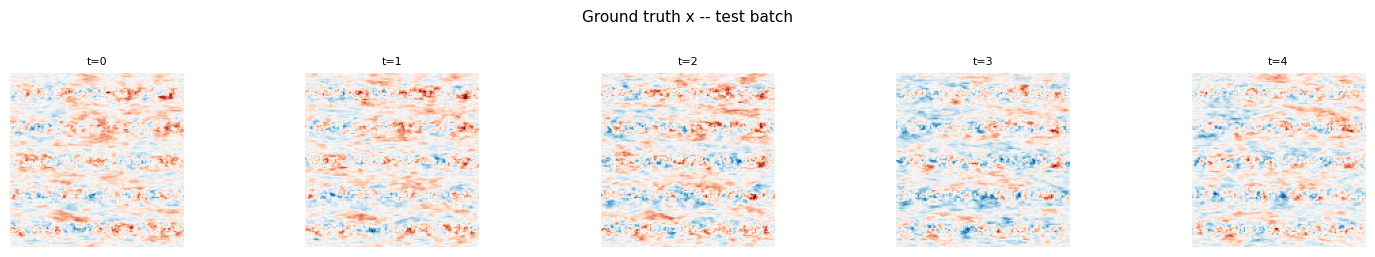

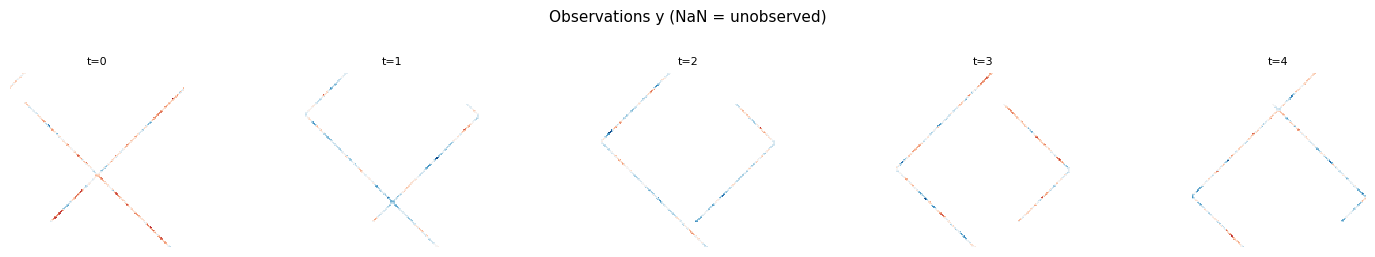

In [13]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

def plot_field(arr: np.ndarray, title: str = "", vmin=None, vmax=None,
               cols: int = 5, cmap: str = "RdBu_r") -> None:
    """Display a field (T, H, W) as a grid."""
    T = arr.shape[0]
    rows = math.ceil(T / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
    axes = np.array(axes).ravel()
    for t in range(T):
        im = axes[t].imshow(arr[t], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        axes[t].set_title(f"t={t}", fontsize=8)
        axes[t].axis("off")
    for ax in axes[T:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


plot_field(batch.tgt[0].float().numpy(),   title="Ground truth x -- test batch")
plot_field(batch.input[0].float().numpy(), title="Observations y (NaN = unobserved)")

### Ensemble Generation (N_SAMPLES members)

Variational sampling:   0%|          | 0/15 [00:00<?, ?it/s]

  Sample 10/10 done
[OK] 10 ensemble members generated
  Sample 10/10 done
[OK] 10 ensemble members generated


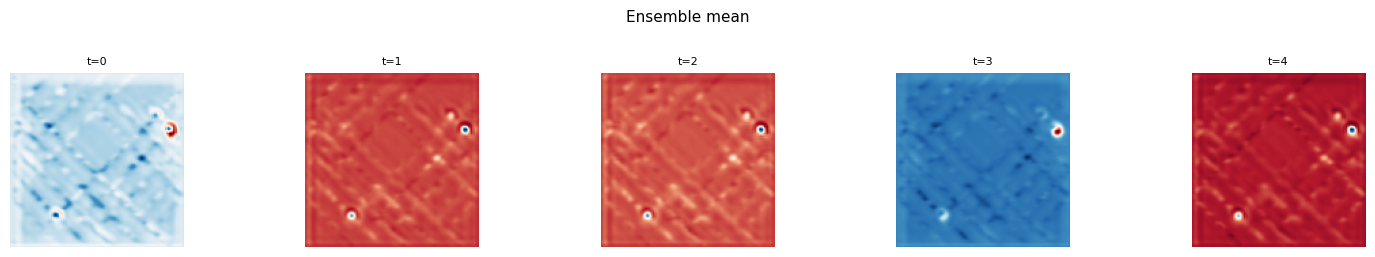

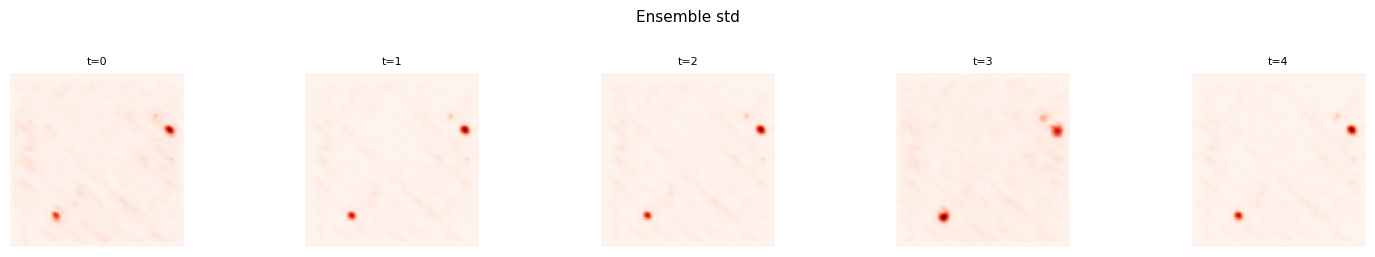

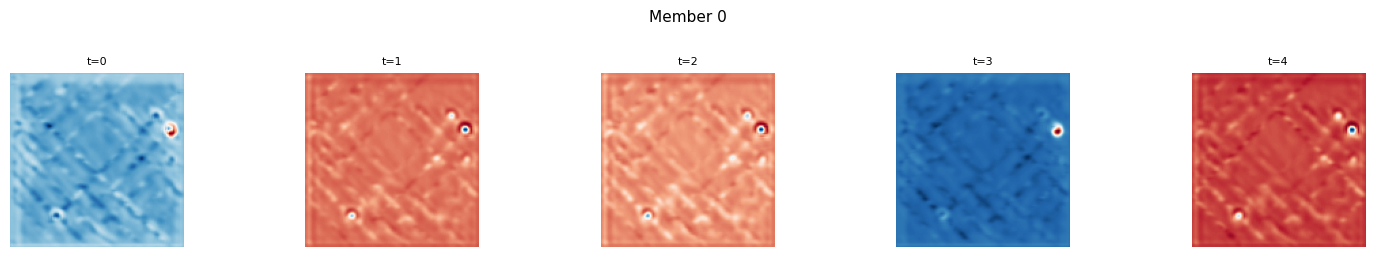

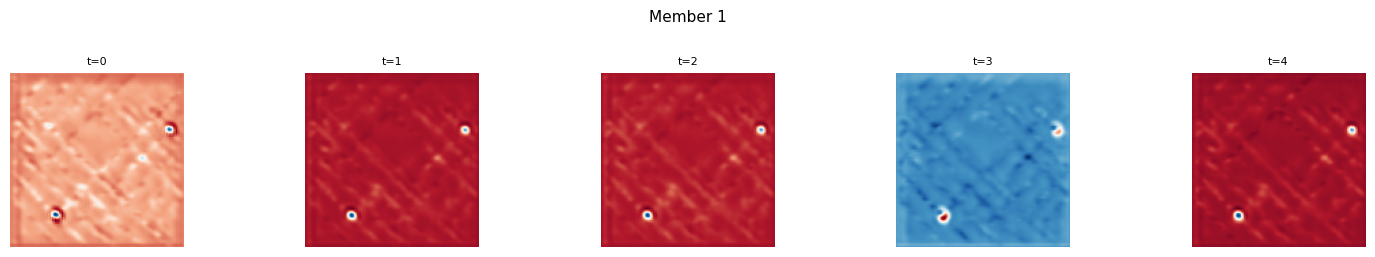

In [14]:
N_SAMPLES = 10
NSTEPS    = 15
variational_sampling = VariationalConsistencySampling(sigma_noise=80.0,
                                                      noise_schedule="cosine", 
                                                      conditioning_mode="obs",
                                                      schedule_power=SCHEDULE_POWER)

C  = datamodule.window_size
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]

samples   = []
samples_process = []

y_dev = batch.input.to(device=device, dtype=dtype)

with torch.no_grad():
    for i in range(N_SAMPLES):
        noise = torch.randn((1, C, H, W), device=device, dtype=dtype)
        sample, sample_process = variational_sampling(
            unet,
            obs_cost,
            prior_cost,
            lambda_reg,
            noise,
            y_dev,
            nsteps=NSTEPS,
            clip_denoised=False,
            verbose=(i == 0),
        )
        samples.append(sample.float().cpu())
        samples_process.append(sample_process.float().cpu())
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")
print(f"\n[OK] {N_SAMPLES} ensemble members generated")

ensemble = torch.stack(samples, dim=0).squeeze(1)   # (N, C, H, W)
ens_mean = ensemble.mean(dim=0)
ens_std  = ensemble.std(dim=0)

plot_field(ens_mean.numpy(),        title="Ensemble mean")
plot_field(ens_std.numpy(),         title="Ensemble std", vmin=0, cmap="Reds")
plot_field(samples[0][0].numpy(),   title="Member 0")
plot_field(samples[1][0].numpy(),   title="Member 1")

## Metrics -- VariationalCM vs OI

- **mu-score** = $1 - \text{RMSE}/\sigma_{\text{GT}}$ (higher is better)
- **RMSE** (lower is better)
- **CRPS** ensemble (lower is better)
- **lambda_x** -- minimum resolved wavelength (radial PSD)
- **Spread-skill ratio** (ideally ~ 1)

In [16]:
# ---- Denormalization ----
m_norm, s_norm = datamodule.norm_stats()

gt_np       = batch.tgt[0].float().numpy()
ens_mean_np = ens_mean.numpy()
ensemble_np = ensemble.numpy()   # (N, C, H, W)

gt_phys       = gt_np       * s_norm + m_norm
ens_mean_phys = ens_mean_np * s_norm + m_norm
ensemble_phys = ensemble_np * s_norm + m_norm

start_t = datamodule.test_ds.indices[0]
ws      = datamodule.window_size
oi_phys = datamodule.oi[start_t : start_t + ws].astype(np.float32)
oi_norm = (oi_phys - m_norm) / s_norm


def compute_psd_and_lambda_x(field: np.ndarray, dx: float = 1.0):
    f = field.copy()
    f[np.isnan(f)] = 0.0
    psd_sum = sum(np.abs(np.fft.fft2(f[t])) ** 2 for t in range(f.shape[0]))
    psd_avg = psd_sum / f.shape[0]
    ny, nx  = psd_avg.shape
    yy, xx  = np.meshgrid(np.arange(ny) - ny // 2, np.arange(nx) - nx // 2, indexing="ij")
    rr      = np.sqrt(xx ** 2 + yy ** 2)
    r_max   = int(np.sqrt((ny // 2) ** 2 + (nx // 2) ** 2))
    radial_psd = np.array([
        np.mean(np.fft.fftshift(psd_avg)[(rr >= r) & (rr < r + 1)])
        if np.any((rr >= r) & (rr < r + 1)) else 0.0
        for r in range(r_max)
    ])
    threshold = 0.5 * np.max(radial_psd[1:])
    idx_50    = np.where(radial_psd < threshold)[0]
    lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan
    return lambda_x, radial_psd


def metrics_vs_gt(pred, gt, label, dx=1.0):
    gt_std   = np.nanstd(gt)
    rmse_v   = np.sqrt(np.nanmean((pred - gt) ** 2))
    mu       = 1.0 - rmse_v / gt_std
    lx_gt,   psd_gt   = compute_psd_and_lambda_x(gt,   dx=dx)
    lx_pred, psd_pred = compute_psd_and_lambda_x(pred, dx=dx)
    spectral = np.corrcoef(psd_gt[:len(psd_gt) // 2], psd_pred[:len(psd_pred) // 2])[0, 1]
    return dict(Method=label, mu_score=mu, RMSE=rmse_v,
                lambda_x_GT=lx_gt, lambda_x_pred=lx_pred, spectral_corr=spectral), psd_pred, psd_gt


row_cm, psd_cm, psd_gt_rad = metrics_vs_gt(ens_mean_phys, gt_phys, "VariationalCM (mean)")
row_oi, psd_oi, _           = metrics_vs_gt(oi_phys,        gt_phys, "OI baseline")

rmse_oi_norm = np.sqrt(np.nanmean((oi_norm    - gt_np) ** 2))
rmse_cm_norm = np.sqrt(np.nanmean((ens_mean_np - gt_np) ** 2))
print(f"RMSE VariationalCM (normalized): {rmse_cm_norm:.4f}")
print(f"RMSE OI            (normalized): {rmse_oi_norm:.4f}")

if HAS_PROPERSCORING:
    crps_values = []
    for t in range(gt_phys.shape[0]):
        for i in range(gt_phys.shape[1]):
            for j in range(gt_phys.shape[2]):
                if not np.isnan(gt_phys[t, i, j]):
                    crps_values.append(crps_ensemble(gt_phys[t, i, j], ensemble_phys[:, t, i, j]))
    crps_mean = np.mean(crps_values)
    print(f"CRPS mean (ensemble)  : {crps_mean:.4f}")
else:
    crps_mean = np.nan

df = pd.DataFrame([row_cm, row_oi]).set_index("Method")
df["mu_score"]      = df["mu_score"].map("{:.4f}".format)
df["RMSE"]          = df["RMSE"].map("{:.4f}".format)
df["lambda_x_GT"]   = df["lambda_x_GT"].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
df["lambda_x_pred"] = df["lambda_x_pred"].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
df["spectral_corr"] = df["spectral_corr"].map("{:.4f}".format)
print("\n## Performance Assessment -- VariationalCM vs OI (SPDE dataset)\n")
print(df.to_markdown())
display(df)

rmse_det = np.sqrt(np.nanmean((ens_mean_phys - gt_phys) ** 2))
spread   = np.nanmean(np.std(ensemble_phys, axis=0))
print(f"\nEnsemble spread (mean std): {spread:.4f}")
print(f"RMSE (ensemble mean)     : {rmse_det:.4f}")
print(f"Spread-skill ratio       : {spread / rmse_det:.4f}  (ideal ~ 1.0)")
if not np.isnan(crps_mean):
    print(f"CRPS                     : {crps_mean:.4f}")

/tmp/ipykernel_3822822/584592307.py:34: RuntimeWarning: divide by zero encountered in divide
  lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan


RMSE VariationalCM (normalized): 1.3168
RMSE OI            (normalized): 0.8942
CRPS mean (ensemble)  : 0.1920

## Performance Assessment -- VariationalCM vs OI (SPDE dataset)

| Method               |   mu_score |   RMSE |   lambda_x_GT |   lambda_x_pred |   spectral_corr |
|:---------------------|-----------:|-------:|--------------:|----------------:|----------------:|
| VariationalCM (mean) |    -0.3249 | 0.3281 |           inf |              64 |          0.1596 |
| OI baseline          |     0.1004 | 0.2228 |           inf |             inf |          0.99   |
CRPS mean (ensemble)  : 0.1920

## Performance Assessment -- VariationalCM vs OI (SPDE dataset)

| Method               |   mu_score |   RMSE |   lambda_x_GT |   lambda_x_pred |   spectral_corr |
|:---------------------|-----------:|-------:|--------------:|----------------:|----------------:|
| VariationalCM (mean) |    -0.3249 | 0.3281 |           inf |              64 |          0.1596 |
| OI baseline          |     0.10

,mu_score,RMSE,lambda_x_GT,lambda_x_pred,spectral_corr
Method,,,,,
VariationalCM (mean),-0.3249,0.3281,inf,64.00,0.1596
OI baseline,0.1004,0.2228,inf,inf,0.9900



Ensemble spread (mean std): 0.0728
RMSE (ensemble mean)     : 0.3281
Spread-skill ratio       : 0.2218  (ideal ~ 1.0)
CRPS                     : 0.1920


### Radial PSD -- VariationalCM vs OI vs GT

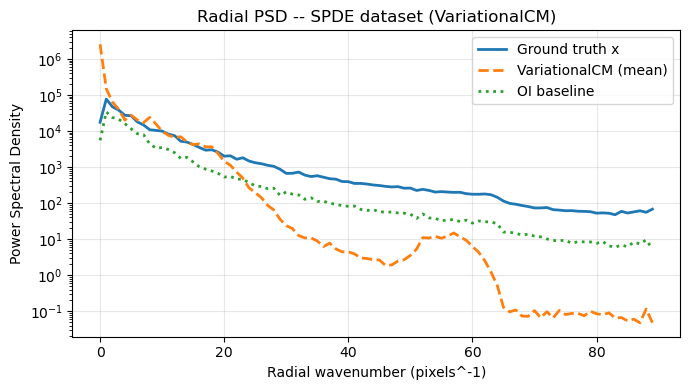

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(psd_gt_rad, label="Ground truth x",         linewidth=2)
ax.semilogy(psd_cm,      label="VariationalCM (mean)",   linewidth=2, linestyle="--")
ax.semilogy(psd_oi,      label="OI baseline",             linewidth=2, linestyle=":")
ax.set_xlabel("Radial wavenumber (pixels^-1)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("Radial PSD -- SPDE dataset (VariationalCM)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visual Comparison -- GT / OI / Prior Phi(x) / VariationalCM

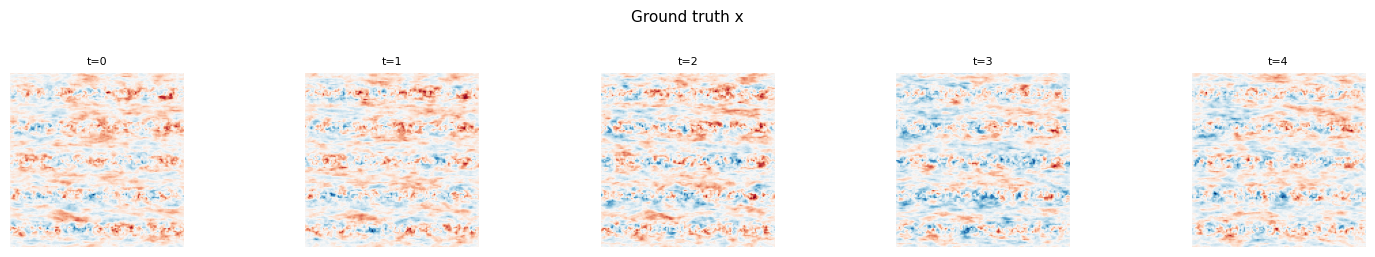

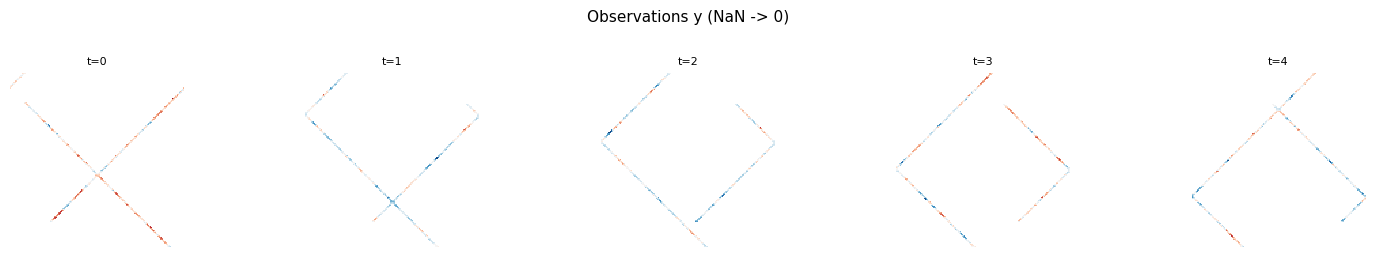

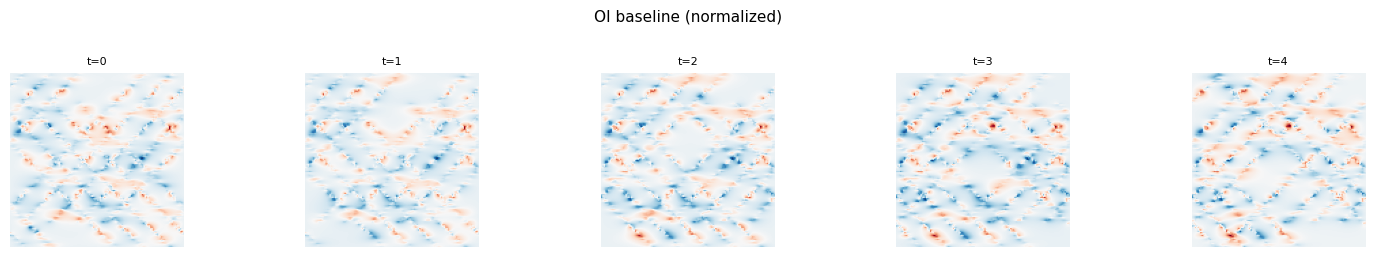

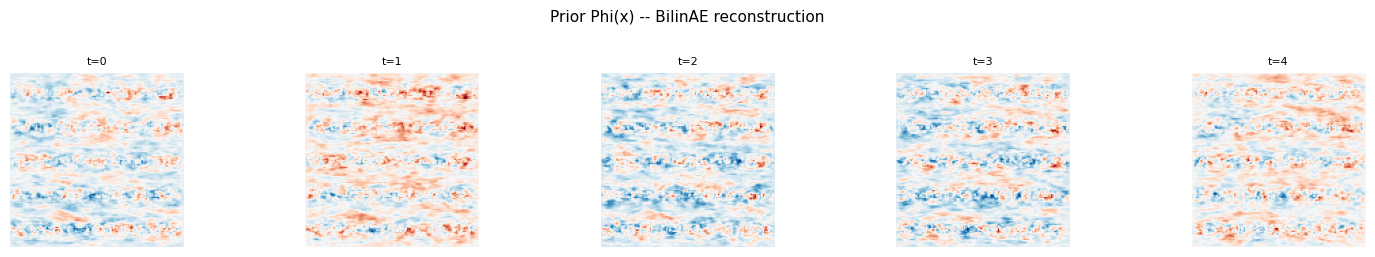

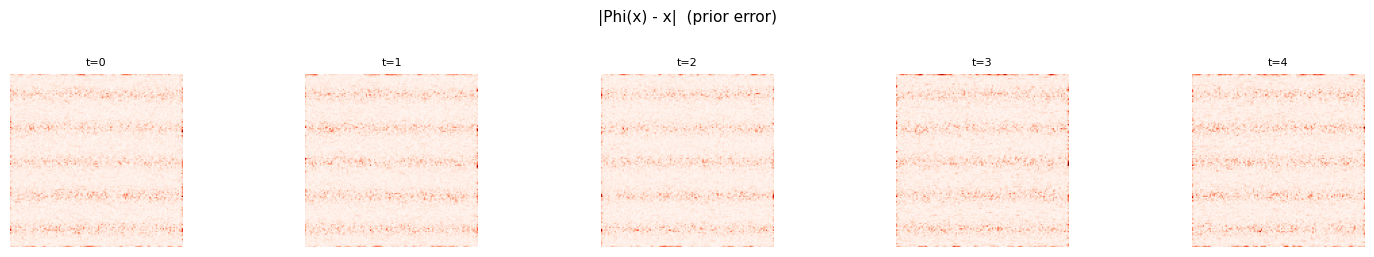

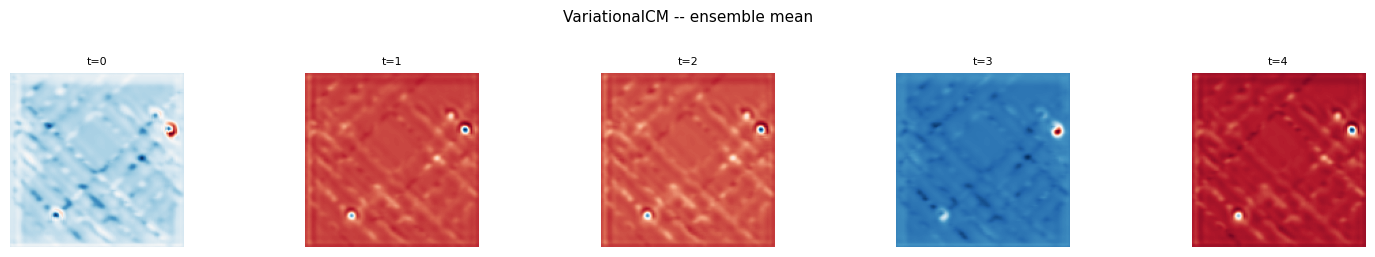

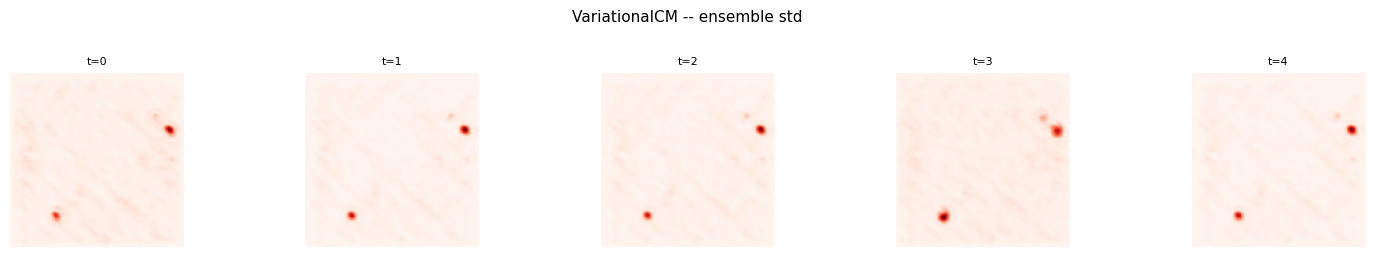

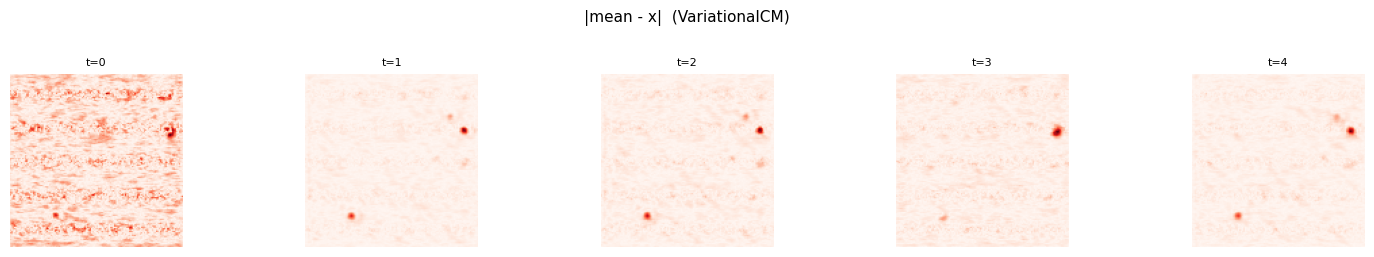

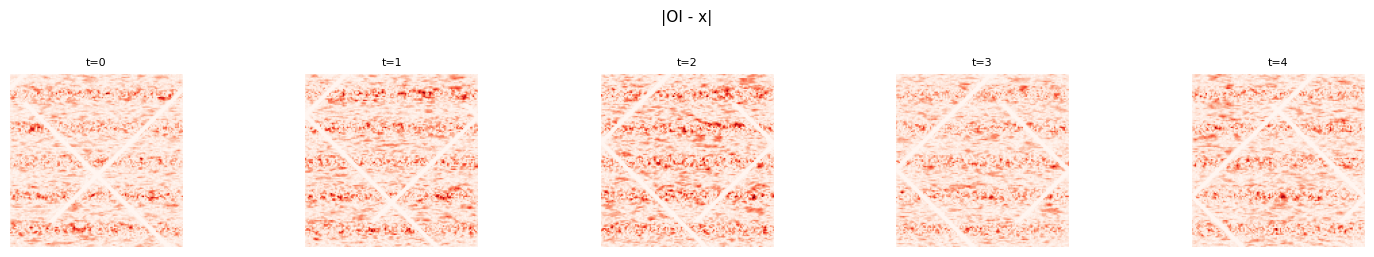

In [18]:
# Prior Phi(x) -- BilinAE reconstruction applied to ground truth
with torch.no_grad():
    tgt_recon = prior_cost.forward_ae(
        batch.tgt.to(device=device, dtype=dtype)
    ).float().cpu()[0]   # (C, H, W)
tgt_recon_np = tgt_recon.numpy()

plot_field(gt_np,                                               title="Ground truth x")
plot_field(batch.input[0].float().numpy(),                      title="Observations y (NaN -> 0)")
plot_field(oi_norm,                                             title="OI baseline (normalized)")
plot_field(tgt_recon_np,                                        title="Prior Phi(x) -- BilinAE reconstruction")
plot_field(np.abs(tgt_recon_np - gt_np),                        title="|Phi(x) - x|  (prior error)",              vmin=0, cmap="Reds")
plot_field(ens_mean_np,                                         title="VariationalCM -- ensemble mean")
plot_field(ens_std.numpy(),                                     title="VariationalCM -- ensemble std",             vmin=0, cmap="Reds")
plot_field(np.abs(ens_mean_np - gt_np),                         title="|mean - x|  (VariationalCM)",              vmin=0, cmap="Reds")
plot_field(np.abs(oi_norm     - gt_np),                         title="|OI - x|",                              vmin=0, cmap="Reds")

### Transport process -- member 0 (sampling steps)

/tmp/ipykernel_3822822/3287129061.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


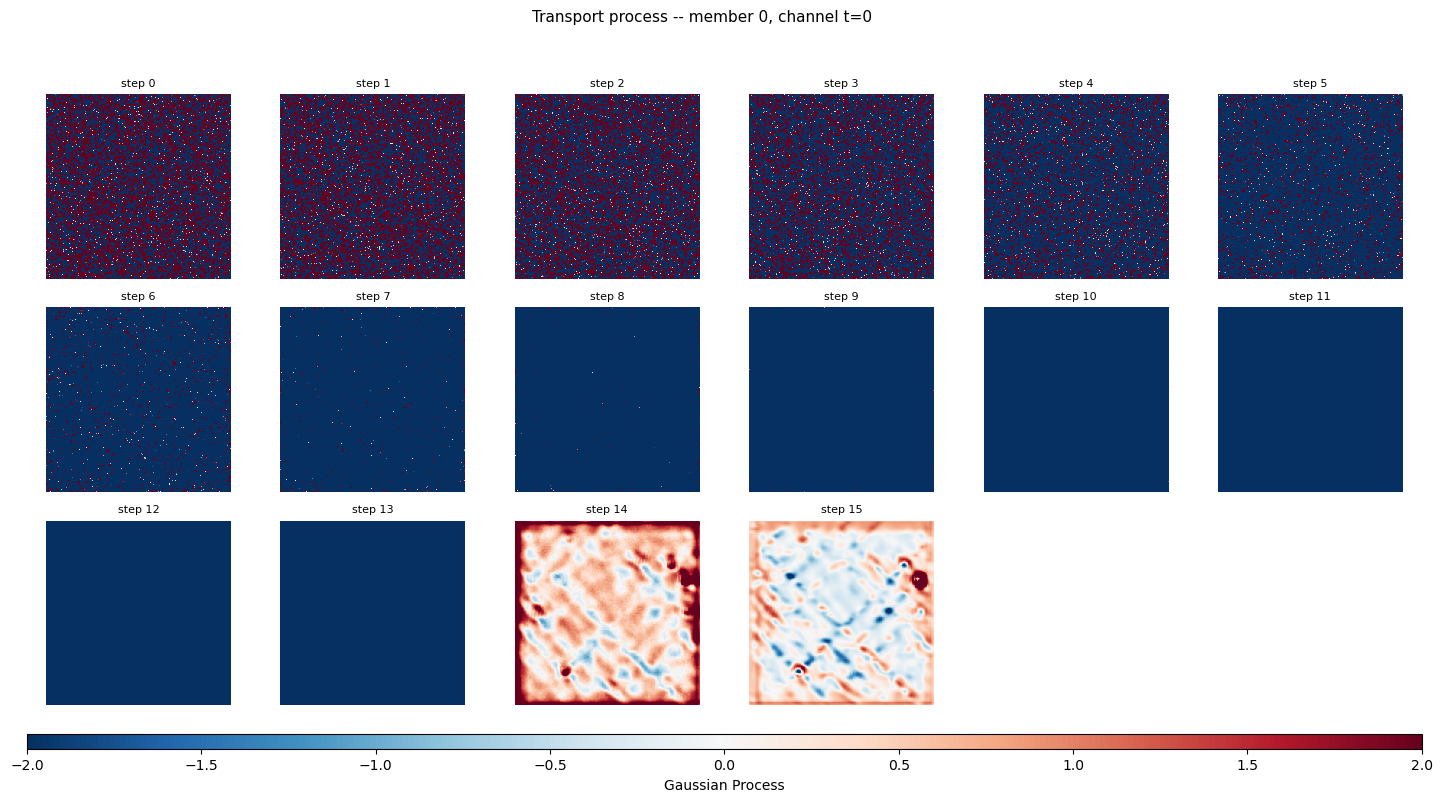

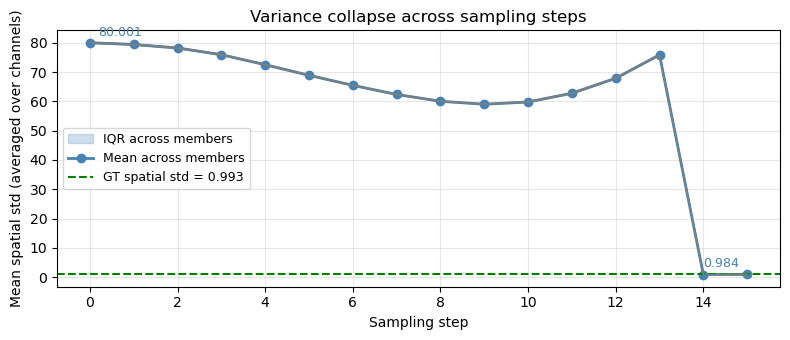

Std at step 0 (pure noise) : 80.0010  (expected ~ 15*sigma_noise if unnormed)
Std at step 15 (final)      : 0.9840
Collapse factor            : 81.30x

--- Spatial std reference (single realization, mean over C channels) ---
  GT spatial std           : 0.9935
  CM final spatial std     : 0.9840
  Ratio CM/GT              : 0.990  (ideal ~ 1.0)

NOTE: Dataset std=1 is over ALL samples×pixels. The spatial std of a single
      SPDE realization (std over H×W) can naturally be much less than 1.
      The relevant check is CM_final_std / GT_spatial_std ~ 1.0


In [19]:

# samples_process[0]: Tensor (nsteps+1, 1, C, H, W)
# Display the evolution of t=0 (channel 0) across sampling steps
process_t0 = samples_process[0][:, 0, 0, :, :]   # (nsteps+1, H, W)
process_np = process_t0.numpy()

vmin = -2
vmax = 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

nsteps_vis = process_np.shape[0]
cols = min(nsteps_vis, 6)
rows = math.ceil(nsteps_vis / cols)

fig = plt.figure(figsize=(3 * cols, 2.5 * rows + 1))

gs = gridspec.GridSpec(
    rows + 1, cols,
    height_ratios=[*([1] * rows), 0.08],
    hspace=0.2,
    wspace=0.05
)

axes = []
for i in range(rows):
    for j in range(cols):
        axes.append(fig.add_subplot(gs[i, j]))

cax = fig.add_subplot(gs[rows, :])

for k in range(nsteps_vis):
    im = axes[k].imshow(
        process_np[k],
        origin="lower",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )
    axes[k].set_title(f"step {k}", fontsize=8)
    axes[k].axis("off")

for ax in axes[nsteps_vis:]:
    ax.axis("off")

cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
cbar.set_label("Gaussian Process")

fig.suptitle("Transport process -- member 0, channel t=0", fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ---- Std decay curve across sampling steps ----
step_stds_all = np.array([
    [
        proc[k, 0].numpy().std(axis=(-2, -1)).mean()  # mean over C channels
        for k in range(nsteps_vis)
    ]
    for proc in samples_process   # one per member
])   # shape: (N_SAMPLES, nsteps+1)

step_stds_mean = step_stds_all.mean(axis=0)   # (nsteps+1,)
step_stds_q25  = np.percentile(step_stds_all, 25, axis=0)
step_stds_q75  = np.percentile(step_stds_all, 75, axis=0)

steps = np.arange(nsteps_vis)

# ---- Reference: spatial std of GT and noise (for interpretation) ----
gt_spatial_std   = batch.tgt[0].float().numpy().std(axis=(-2, -1)).mean()   # mean over C
noise_spatial_std = step_stds_mean[0]   # initial state (sigma_noise * randn)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.fill_between(steps, step_stds_q25, step_stds_q75,
                alpha=0.25, color="steelblue", label="IQR across members")
ax.plot(steps, step_stds_mean, marker="o", linewidth=2,
        color="steelblue", label="Mean across members")
# GT spatial std reference line
ax.axhline(gt_spatial_std, color="green", linewidth=1.5, linestyle="--",
           label=f"GT spatial std = {gt_spatial_std:.3f}")
# Individual members
for i, row in enumerate(step_stds_all):
    ax.plot(steps, row, linewidth=0.6, alpha=0.4, color="gray")

ax.set_xlabel("Sampling step")
ax.set_ylabel("Mean spatial std (averaged over channels)")
ax.set_title("Variance collapse across sampling steps")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate first and last
ax.annotate(f"{step_stds_mean[0]:.3f}", (0, step_stds_mean[0]),
            textcoords="offset points", xytext=(6, 5), fontsize=9, color="steelblue")
ax.annotate(f"{step_stds_mean[-1]:.3f}", (nsteps_vis - 1, step_stds_mean[-1]),
            textcoords="offset points", xytext=(-32, 5), fontsize=9, color="steelblue")

plt.tight_layout()
plt.show()

print(f"Std at step 0 (pure noise) : {step_stds_mean[0]:.4f}  (expected ~ {NSTEPS}*sigma_noise if unnormed)")
print(f"Std at step {nsteps_vis-1} (final)      : {step_stds_mean[-1]:.4f}")
print(f"Collapse factor            : {step_stds_mean[0] / max(step_stds_mean[-1], 1e-8):.2f}x")
print()
print("--- Spatial std reference (single realization, mean over C channels) ---")
print(f"  GT spatial std           : {gt_spatial_std:.4f}")
print(f"  CM final spatial std     : {step_stds_mean[-1]:.4f}")
print(f"  Ratio CM/GT              : {step_stds_mean[-1] / max(gt_spatial_std, 1e-8):.3f}  (ideal ~ 1.0)")
print()
print("NOTE: Dataset std=1 is over ALL samples×pixels. The spatial std of a single")
print("      SPDE realization (std over H×W) can naturally be much less than 1.")
print("      The relevant check is CM_final_std / GT_spatial_std ~ 1.0")
